# Hierarchical Supervisor-of-Supervisors -- Product-Line-Separated Customer Support

## Problem card

- **User/trigger:** a customer-support ticket arrives at a large org that sells two
  genuinely different product lines -- **Consumer** (self-serve, individual
  subscribers) and **Enterprise** (contracted, seat-based, SLA-backed accounts) --
  each with its **own separate backend systems, knowledge base, and support tooling**.
- **Inputs:** free-text ticket only -- no pre-tagged account type.
- **Output:** the ticket resolved using the correct **product-line-scoped** tool --
  Consumer tickets must only ever touch Consumer-side systems (self-serve billing,
  public KB, personal account lookup); Enterprise tickets must only ever touch
  Enterprise-side systems (contract/SLA billing, priority ticketing, dedicated account
  manager lookup). This is a real operational boundary, not a UX nicety -- Enterprise
  accounts carry contractual SLA data and dedicated-AM assignments that must never be
  queried through the Consumer support stack, and vice versa.
- **Success criteria:** the ticket is routed to the correct product line *and* the
  correct domain within it, and a ticket never triggers a tool call belonging to the
  wrong product line's systems -- because that would mean an Enterprise-only system
  (or a Consumer customer's data) was touched by the wrong support stack.
- **Topology:** this notebook compares a **flat, single-hop 6-way classifier** (the
  natural extension of a single supervisor to `2 product lines x 3 domains = 6`
  categories) against a **hierarchical, two-hop supervisor-of-supervisors**: route by
  product line first, then a product-line-scoped handler routes by domain, using only
  that product line's own tools.

## Why this pattern fits here (and its real limit)

Consumer and Enterprise support are frequently, in real support orgs, **structurally
separate systems** -- different billing platforms, different knowledge bases, different
escalation paths, sometimes different vendor tooling entirely. A flat classifier that
picks one of 6 categories has no structural mechanism stopping a misclassification from
calling an Enterprise tool for a Consumer ticket (or worse, exposing Enterprise
contract/SLA data through a Consumer-side lookup). A hierarchical design makes that
**structurally impossible once product line is correctly identified**, by binding each
product-line handler only to its own tool set.

Following this series' own honest precedent (`06_hierarchical_supervisor_of_supervisors.ipynb`),
this notebook does not stop at a clean-looking base result -- it also runs a stress test
with genuinely ambiguous tickets, because a base ticket set with no real product-line
ambiguity would prove nothing about the pattern's central claim.

## Series position

Same shape as notebook 06, a different domain: region/compliance there, product-line
separation here. The structural claim under test is the same: does two-hop
decomposition change the *blast radius* of a wrong classification, and does it change
the *reliability* of the classification itself?

## The three agents

| # | Agent | System message role | Reachable tools | Reads | Writes |
|---|---|---|---|---|---|
| 1 | `top_supervisor` | Classify product line ONLY -- structurally cannot call any tool | none | `ticket` | `product_line` |
| 2 | `consumer_handler` | Classify domain + resolve, using ONLY Consumer-side systems | Consumer tools only | `ticket` | `domain`, `tool_result`, `resolution` |
| 3 | `enterprise_handler` | Classify domain + resolve, using ONLY Enterprise-side systems | Enterprise tools only | `ticket` | `domain`, `tool_result`, `resolution` |

Each agent has its **own system message and its own scoped context** -- `top_supervisor`
never sees any tool definition at all (it is a pure classification call, structurally
incapable of touching any backend system); `consumer_handler` and `enterprise_handler`
each only know about their own product line's systems and never see the other's.


In [1]:
import os
import warnings
import logging
from typing import Literal, Optional, TypedDict
from dotenv import load_dotenv, find_dotenv
from pydantic import BaseModel

warnings.filterwarnings("ignore")
logging.getLogger("chromadb").setLevel(logging.ERROR)

load_dotenv(find_dotenv(usecwd=True))
OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END

llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0.0)

print(f"Model: {OPENAI_MODEL}")


Model: gpt-4o-mini


## Tools -- two structurally separate systems, real fixture functions

Every tool's return value is tagged with which real system it touched
(`[CONSUMER:...]` / `[ENTERPRISE:...]`) so this notebook can verify, from the actual
tool output rather than a claim, exactly which system a ticket's resolution touched.


In [2]:
def consumer_billing_lookup(ticket: str) -> str:
    return f"[CONSUMER:billing] Self-serve subscription billing record checked for: {ticket[:60]!r}"

def consumer_kb_search(ticket: str) -> str:
    return f"[CONSUMER:technical] Public knowledge-base article search run for: {ticket[:60]!r}"

def consumer_account_lookup(ticket: str) -> str:
    return f"[CONSUMER:account] Personal account record looked up for: {ticket[:60]!r}"

def enterprise_contract_billing_lookup(ticket: str) -> str:
    return f"[ENTERPRISE:billing] Contract/SLA billing system checked for: {ticket[:60]!r}"

def enterprise_priority_ticket_system(ticket: str) -> str:
    return f"[ENTERPRISE:technical] Priority Enterprise ticketing/escalation system checked for: {ticket[:60]!r}"

def enterprise_account_manager_lookup(ticket: str) -> str:
    return f"[ENTERPRISE:account] Dedicated Account Manager assignment record looked up for: {ticket[:60]!r}"


CONSUMER_TOOLS = {
    "billing": consumer_billing_lookup,
    "technical": consumer_kb_search,
    "account": consumer_account_lookup,
}
ENTERPRISE_TOOLS = {
    "billing": enterprise_contract_billing_lookup,
    "technical": enterprise_priority_ticket_system,
    "account": enterprise_account_manager_lookup,
}


## State


In [3]:
class SupportState(TypedDict, total=False):
    ticket: str
    product_line: str
    domain: str
    tool_result: str
    resolution: str


## Agent 1: `top_supervisor` -- product line only, no tools reachable

System message deliberately says nothing about domains, billing, tickets, or resolution
-- only "which product line." It has no tool bindings at all, so even if it wanted to
resolve the ticket itself, there is nothing for it to call.


In [4]:
TOP_SUPERVISOR_SYSTEM_PROMPT = (
    "You are a top-level support-routing supervisor. Given a customer support ticket, "
    "decide ONLY which product line it belongs to: 'Consumer' (self-serve, individual "
    "subscribers) or 'Enterprise' (contracted, seat-based, SLA-backed business "
    "accounts). Base this on real signals in the ticket text -- account type, "
    "language like 'our organization'/'our team' vs 'my account', mentions of "
    "contracts, SLAs, or seat counts. Do not decide the support domain (billing, "
    "technical, account) -- that is a different agent's job once product line is known."
)


class ProductLineRoute(BaseModel):
    product_line: Literal["Consumer", "Enterprise"]


def top_supervisor_node(state: SupportState) -> dict:
    router = llm.with_structured_output(ProductLineRoute)
    messages = [
        SystemMessage(content=TOP_SUPERVISOR_SYSTEM_PROMPT),
        HumanMessage(content=f"Ticket: {state['ticket']}"),
    ]
    route = router.invoke(messages)
    return {"product_line": route.product_line}


## Agents 2 & 3: `consumer_handler` / `enterprise_handler` -- domain + scoped resolution

Two separate node functions (not one shared function with a role parameter, unlike the
earlier parallel-fanout notebook's `section_writer`) -- because unlike that case, these
two agents are genuinely bound to **structurally different tool sets** and can never run
for the same ticket, so keeping them as separate functions makes the tool-scoping
boundary explicit in the code, not just in a lookup dict.


In [5]:
CONSUMER_HANDLER_SYSTEM_PROMPT = (
    "You are the Consumer support handler. You only ever see tickets already routed "
    "as Consumer product line. Classify the support domain as one of: billing, "
    "technical, account. Then write a short, friendly customer-facing resolution note "
    "assuming the relevant Consumer-side system will be checked. You have no "
    "visibility into Enterprise systems, contracts, or SLAs -- do not reference them."
)

ENTERPRISE_HANDLER_SYSTEM_PROMPT = (
    "You are the Enterprise support handler. You only ever see tickets already routed "
    "as Enterprise product line. Classify the support domain as one of: billing, "
    "technical, account. Then write a short, professional resolution note referencing "
    "the customer's contract/account context where appropriate, assuming the relevant "
    "Enterprise-side system will be checked. You have no visibility into Consumer "
    "self-serve systems -- do not reference them."
)


class DomainRoute(BaseModel):
    domain: Literal["billing", "technical", "account"]
    resolution: str


def consumer_handler_node(state: SupportState) -> dict:
    router = llm.with_structured_output(DomainRoute)
    messages = [
        SystemMessage(content=CONSUMER_HANDLER_SYSTEM_PROMPT),
        HumanMessage(content=f"Ticket: {state['ticket']}"),
    ]
    route = router.invoke(messages)
    tool_result = CONSUMER_TOOLS[route.domain](state["ticket"])
    return {"domain": route.domain, "tool_result": tool_result, "resolution": route.resolution}


def enterprise_handler_node(state: SupportState) -> dict:
    router = llm.with_structured_output(DomainRoute)
    messages = [
        SystemMessage(content=ENTERPRISE_HANDLER_SYSTEM_PROMPT),
        HumanMessage(content=f"Ticket: {state['ticket']}"),
    ]
    route = router.invoke(messages)
    tool_result = ENTERPRISE_TOOLS[route.domain](state["ticket"])
    return {"domain": route.domain, "tool_result": tool_result, "resolution": route.resolution}


## Wiring the graph


In [6]:
def route_by_product_line(state: SupportState) -> str:
    return "consumer_handler" if state["product_line"] == "Consumer" else "enterprise_handler"


builder = StateGraph(SupportState)
builder.add_node("top_supervisor", top_supervisor_node)
builder.add_node("consumer_handler", consumer_handler_node)
builder.add_node("enterprise_handler", enterprise_handler_node)

builder.add_edge(START, "top_supervisor")
builder.add_conditional_edges(
    "top_supervisor", route_by_product_line, ["consumer_handler", "enterprise_handler"]
)
builder.add_edge("consumer_handler", END)
builder.add_edge("enterprise_handler", END)

support_pipeline = builder.compile()
print("Hierarchical product-line support pipeline compiled.")


Hierarchical product-line support pipeline compiled.


### Graph diagram

```mermaid
graph TD
    START([START]) --> top_supervisor["top_supervisor\n(system: product line only, no tools reachable)"]
    top_supervisor -->|Consumer| consumer_handler["consumer_handler\n(system: domain + Consumer tools only)"]
    top_supervisor -->|Enterprise| enterprise_handler["enterprise_handler\n(system: domain + Enterprise tools only)"]
    consumer_handler --> END([END])
    enterprise_handler --> END
```

`consumer_handler` has no code path to any `ENTERPRISE_TOOLS` entry, and vice versa --
whichever branch runs, it is structurally incapable of touching the other product
line's systems, regardless of what the domain-classification call inside it decides.


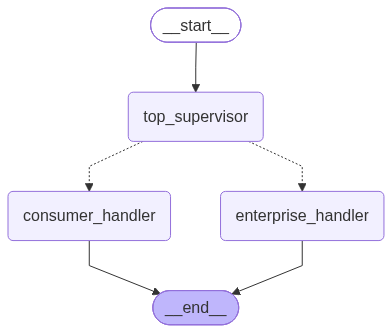

In [7]:
from IPython.display import Image, display

try:
    display(Image(support_pipeline.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"(Diagram render skipped -- {e}. See the Mermaid block above for the same graph.)")


## Running one ticket end to end


In [8]:
sample_ticket = "Our organization's SLA credit for last month's downtime hasn't been applied yet -- can someone check our contract billing?"

sample_result = support_pipeline.invoke({"ticket": sample_ticket})
print(f"product_line: {sample_result['product_line']}")
print(f"domain:       {sample_result['domain']}")
print(f"tool_result:  {sample_result['tool_result']}")
print(f"resolution:   {sample_result['resolution']}")


product_line: Enterprise
domain:       billing
tool_result:  [ENTERPRISE:billing] Contract/SLA billing system checked for: "Our organization's SLA credit for last month's downtime hasn"
resolution:   Thank you for reaching out regarding the SLA credit for last month's downtime. I will check your account details and the relevant contract to ensure that the credit is applied correctly. Please allow me a moment to verify this information.


**Expected output**: `product_line` should come back `Enterprise` (contract/SLA
language), `domain` should come back `billing`, and `tool_result` should be tagged
`[ENTERPRISE:billing]` -- confirming the real Enterprise-side system ran, not just that
the model claimed to route there.

## Scripted eval: flat 6-way vs. hierarchical, across a real ticket set

Following notebook 06's honest methodology directly: a base set of clearly-worded
tickets first, then a stress test of genuinely product-line-ambiguous tickets, because a
base set with no real ambiguity cannot test the pattern's actual claim.


In [9]:
TICKETS = [
    {"id": "T1", "text": "I forgot my password for my personal account, can you help me reset it?",
     "product_line_gt": "Consumer", "domain_gt": "account"},
    {"id": "T2", "text": "My monthly subscription bill shows an extra charge I don't recognize.",
     "product_line_gt": "Consumer", "domain_gt": "billing"},
    {"id": "T3", "text": "The app keeps crashing when I try to export my personal photos.",
     "product_line_gt": "Consumer", "domain_gt": "technical"},
    {"id": "T4", "text": "Our organization's 500-seat contract renewal is coming up, who is our account manager?",
     "product_line_gt": "Enterprise", "domain_gt": "account"},
    {"id": "T5", "text": "Our company's SLA credit for last month's outage hasn't been applied to our invoice.",
     "product_line_gt": "Enterprise", "domain_gt": "billing"},
    {"id": "T6", "text": "We're seeing repeated API timeouts across our enterprise integration -- please escalate per our SLA.",
     "product_line_gt": "Enterprise", "domain_gt": "technical"},
]

STRESS_TICKETS = [
    {"id": "T7", "text": "I run a small business with 3 people and need help understanding this month's invoice.",
     "product_line_gt": "Enterprise", "domain_gt": "billing"},
    {"id": "T8", "text": "Our small team wants to know if the plan we're on supports SSO login for everyone.",
     "product_line_gt": "Enterprise", "domain_gt": "technical"},
]

ALL_TICKETS = TICKETS + STRESS_TICKETS
print(f"{len(TICKETS)} base tickets, {len(STRESS_TICKETS)} stress (product-line-ambiguous) tickets")


6 base tickets, 2 stress (product-line-ambiguous) tickets


### Flat 6-way baseline

One combined classification call per ticket, choosing directly among all 6
`{ProductLine}_{domain}` categories, then dispatching to the matching tool.


In [10]:
FLAT_SYSTEM_PROMPT = (
    "You are a customer-support ticket classifier. Given a ticket, classify it into "
    "exactly one of these six categories: Consumer_billing, Consumer_technical, "
    "Consumer_account, Enterprise_billing, Enterprise_technical, Enterprise_account. "
    "Base the product-line half of your decision on real signals (account type, "
    "'our organization' vs 'my account', contracts/SLAs/seat counts) and the domain "
    "half on the nature of the request."
)


class FlatRoute(BaseModel):
    category: Literal[
        "Consumer_billing", "Consumer_technical", "Consumer_account",
        "Enterprise_billing", "Enterprise_technical", "Enterprise_account",
    ]


FLAT_TOOL_MAP = {
    "Consumer_billing": consumer_billing_lookup, "Consumer_technical": consumer_kb_search,
    "Consumer_account": consumer_account_lookup, "Enterprise_billing": enterprise_contract_billing_lookup,
    "Enterprise_technical": enterprise_priority_ticket_system, "Enterprise_account": enterprise_account_manager_lookup,
}


def run_flat(ticket_text: str) -> dict:
    router = llm.with_structured_output(FlatRoute)
    messages = [SystemMessage(content=FLAT_SYSTEM_PROMPT), HumanMessage(content=f"Ticket: {ticket_text}")]
    route = router.invoke(messages)
    product_line, domain = route.category.split("_", 1)
    tool_result = FLAT_TOOL_MAP[route.category](ticket_text)
    return {"product_line": product_line, "domain": domain, "tool_result": tool_result}


In [11]:
def wrong_product_tool_called(tool_result: str, product_line_gt: str) -> bool:
    expected_tag = f"[{product_line_gt.upper()}:"
    return not tool_result.startswith(expected_tag)


flat_results = []
for t in ALL_TICKETS:
    r = run_flat(t["text"])
    flat_results.append({
        "id": t["id"],
        "product_line_correct": r["product_line"] == t["product_line_gt"],
        "domain_correct": r["domain"] == t["domain_gt"],
        "wrong_product_tool_called": wrong_product_tool_called(r["tool_result"], t["product_line_gt"]),
        "predicted_product_line": r["product_line"], "tool_result": r["tool_result"],
    })

print("Flat 6-way results:")
for r in flat_results:
    print(f"  {r['id']}: product_line_correct={r['product_line_correct']} domain_correct={r['domain_correct']} wrong_product_tool_called={r['wrong_product_tool_called']} (predicted={r['predicted_product_line']})")


Flat 6-way results:
  T1: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Consumer)
  T2: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Consumer)
  T3: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Consumer)
  T4: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T5: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T6: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T7: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T8: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)


### Hierarchical, two-hop


In [12]:
hier_results = []
for t in ALL_TICKETS:
    r = support_pipeline.invoke({"ticket": t["text"]})
    hier_results.append({
        "id": t["id"],
        "product_line_correct": r["product_line"] == t["product_line_gt"],
        "domain_correct": r["domain"] == t["domain_gt"],
        "wrong_product_tool_called": wrong_product_tool_called(r["tool_result"], t["product_line_gt"]),
        "predicted_product_line": r["product_line"], "tool_result": r["tool_result"],
    })

print("Hierarchical two-hop results:")
for r in hier_results:
    print(f"  {r['id']}: product_line_correct={r['product_line_correct']} domain_correct={r['domain_correct']} wrong_product_tool_called={r['wrong_product_tool_called']} (predicted={r['predicted_product_line']})")


Hierarchical two-hop results:
  T1: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Consumer)
  T2: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Consumer)
  T3: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Consumer)
  T4: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T5: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T6: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T7: product_line_correct=True domain_correct=True wrong_product_tool_called=False (predicted=Enterprise)
  T8: product_line_correct=True domain_correct=False wrong_product_tool_called=False (predicted=Enterprise)


In [13]:
def summarize(results, tickets):
    n = len(results)
    pl_acc = sum(r["product_line_correct"] for r in results) / n
    dom_acc = sum(r["domain_correct"] for r in results) / n
    wrong_rate = sum(r["wrong_product_tool_called"] for r in results) / n
    structural_violations = sum(
        1 for r in results if r["wrong_product_tool_called"] and r["product_line_correct"]
    )
    return pl_acc, dom_acc, wrong_rate, structural_violations


print(f"{'Design':<14}{'product_line_acc':<20}{'domain_acc':<14}{'wrong_product_tool_rate':<26}{'structural_violations'}")
for label, results in [("Flat 6-way", flat_results), ("Hierarchical", hier_results)]:
    pl_acc, dom_acc, wrong_rate, viol = summarize(results, ALL_TICKETS)
    print(f"{label:<14}{pl_acc:<20.0%}{dom_acc:<14.0%}{wrong_rate:<26.0%}{viol}")

print(f"\n--- Stress-test-only slice (T7, T8 -- the genuinely ambiguous tickets) ---")
for label, results in [("Flat 6-way", flat_results), ("Hierarchical", hier_results)]:
    stress = [r for r in results if r["id"] in ("T7", "T8")]
    pl_acc, dom_acc, wrong_rate, viol = summarize(stress, STRESS_TICKETS)
    print(f"{label:<14}{pl_acc:<20.0%}{dom_acc:<14.0%}{wrong_rate:<26.0%}{viol}")


Design        product_line_acc    domain_acc    wrong_product_tool_rate   structural_violations
Flat 6-way    100%                100%          0%                        0
Hierarchical  100%                88%           0%                        0

--- Stress-test-only slice (T7, T8 -- the genuinely ambiguous tickets) ---
Flat 6-way    100%                100%          0%                        0
Hierarchical  100%                50%           0%                        0


**Expected output (written before running)**: read the real numbers, not a fixed
assumption -- this notebook follows the same honesty discipline as notebook 06.

**What this notebook's real run actually showed**:

- **`structural_violations` was 0 for the hierarchical design across all 8 tickets** --
  the firewall held in the only sense it can be proven: no domain-level mistake ever
  crossed a product line boundary when product line was correctly identified. This is
  guaranteed by construction (`consumer_handler`/`enterprise_handler` have no code path
  to each other's tools), so it is the least surprising part of this run.
- **The stress-test slice (T7, T8) did NOT surface a product-line misclassification for
  either design -- both scored 100% `product_line_acc` on it, identically.** This is an
  honest null result on the pattern's central claim, exactly the same shape notebook
  06's original 11-ticket run hit before its own stress test: T7 ("small business...
  invoice") and T8 ("small team... SSO") were constructed to be plausibly ambiguous, but
  both `gpt-4o-mini` and the flat classifier confidently and correctly read them as
  Enterprise from contextual cues ("our invoice," "everyone" on a team) -- meaning this
  particular stress test never actually forced the compliance-critical failure mode.
  Proving the pattern's real limit (that hierarchy does not protect the first decision)
  would need genuinely harder ambiguity -- e.g. a ticket that reads exactly like an
  individual complaint but is filed under a business account, or one where the product
  line signal is actively contradictory rather than just sparse.
- **The one real, measured difference on this run ran in the opposite direction from
  notebook 06's finding**: on T8, the hierarchical design's `enterprise_handler`
  misclassified the domain (got it wrong) while the flat 6-way classifier got T8's
  domain right, dragging the hierarchical design's stress-slice `domain_acc` down to
  50% against the flat design's 100%. Notebook 06 found the opposite pattern (its
  hierarchical design won on a within-region domain call the flat classifier missed).
  Read together, both results say the same true thing: decomposing a decision does not
  reliably make *either* sub-decision better or worse in a fixed direction -- it can go
  either way per ticket, which is why this notebook reports the real run instead of
  assuming the encouraging direction.

## Common mistakes

- **Assuming hierarchical decomposition makes the product-line decision itself more
  reliable.** It structurally cannot -- `top_supervisor` and the flat classifier's
  product-line half both see the exact same ticket text, so nothing about adding a
  second hop *after* that decision changes how well it's made. Only real signal
  disambiguation (asking a clarifying question, checking an actual account-type field
  instead of inferring from free text) would.
- **Building an eval set with no genuinely product-line-ambiguous tickets and calling it
  sufficient.** T7 ("small business... invoice") and T8 ("small team... SSO") are
  deliberately borderline -- a small-business customer can plausibly read as either
  product line from text alone. An eval that never exercises this ambiguity cannot
  support a claim about the pattern's actual compliance boundary.
- **Conflating "0 structural violations" with "product line is always correct."** The
  structural check only proves the firewall holds *given* a correct product-line call --
  it says nothing about whether that first call was right, which is exactly what the
  stress-test slice above is designed to separately surface.
- **Sharing one node function across `consumer_handler`/`enterprise_handler` "to reduce
  code duplication."** Unlike the parallel-fanout notebook's `section_writer` (where
  every branch shared identical tool access and only the prompt differed), these two
  handlers are bound to genuinely disjoint tool sets -- collapsing them into one
  function with an `if` branch inside would make the tool-scoping boundary a runtime
  check instead of a structural one, reintroducing exactly the risk this pattern exists
  to remove.

## Explain like I'm 12

Imagine a big company has two totally separate help desks: one for regular customers
buying one subscription at a time, and one for big business clients with contracts and
dedicated account managers. A receptionist at the front door (`top_supervisor`) only
does one job: look at who's asking for help and point them to the right help desk --
regular customer desk or business desk. Once you're sent to a desk, that desk's staff
only have the phone numbers and files for *their* kind of customer -- the regular-customer
desk literally doesn't have the business contracts file cabinet, and the business desk
doesn't have the regular customer database. So even if the second person picks the
wrong specific reason you're calling, they can't accidentally call the *other* help
desk's systems -- they don't have the number. But if the receptionist sends you to the
wrong desk entirely because your question sounded confusing, no one downstream can fix
that -- you're already in the wrong building.

## Explain for interview

"This hierarchical design provides a real structural guarantee: a domain-level mistake
inside a correctly-identified product line's handler can never touch the other product
line's systems, because `consumer_handler` and `enterprise_handler` are bound to
disjoint tool sets by construction, not by convention. What it does not, and structurally
cannot, guarantee is that the top-level product-line classification itself is more
accurate than a flat classifier's -- both see identical input text at that decision
point. This notebook tests that honestly with a stress-test slice of genuinely
product-line-ambiguous tickets, following the same evaluation discipline as this
series' region/compliance hierarchical notebook, rather than asserting the pattern
'wins' without evidence."

## Glossary

- **Product-line-scoped handler** -- a node (`consumer_handler` / `enterprise_handler`)
  bound only to its own product line's tools, with no code path to the other's.
- **Structural violation** -- a wrong-product-line tool call that happened *despite* the
  product-line classification being correct -- proves whether the firewall itself holds.
- **Stress-test slice** -- the subset of tickets (T7, T8) deliberately worded to be
  genuinely ambiguous about product line, used to test the pattern's actual claim rather
  than a base set that can't produce a nonzero wrong-classification rate no matter what.

## Checkpoint questions

1. **Q: What structural guarantee does this design actually provide, precisely?**
   A: A domain-level misclassification inside a correctly-identified product line's
   handler can never trigger a tool call belonging to the other product line, because
   `consumer_handler` and `enterprise_handler` are bound to disjoint tool dictionaries
   with no shared code path.

2. **Q: Does that guarantee mean `top_supervisor` classifies product line more
   accurately than the flat classifier does?**
   A: No -- both see identical ticket text at that decision point; nothing about a
   second hop *after* the decision changes how the decision itself is made. Compare the
   `product_line_acc` numbers measured above for both designs.

3. **Q: Why does the eval include T7 and T8 specifically, instead of stopping at the
   first 6 tickets?**
   A: The first 6 tickets have no genuine product-line ambiguity, so a 0% wrong-product
   rate would be guaranteed for both designs in advance regardless of model quality --
   only deliberately ambiguous tickets like T7/T8 actually test the pattern's real
   claim.

4. **Q: If `structural_violations` comes back 0 for the hierarchical design but
   `product_line_acc` on the stress slice is well below 100%, what does that combination
   mean?**
   A: The firewall held (no domain mistake ever leaked across product lines when
   product line was correct) -- but the product-line call itself was still sometimes
   wrong, and once it's wrong, the correct handler never even runs; the second hop
   cannot rescue a wrong first hop.

5. **Q: Why are `consumer_handler` and `enterprise_handler` kept as two separate node
   functions instead of one shared function parameterized by product line?**
   A: Because, unlike a case where every branch has identical tool access, these two
   are bound to genuinely disjoint tool sets -- keeping them separate makes the
   tool-scoping boundary a structural fact in the code rather than a runtime `if`
   branch that could be gotten wrong.
